In [2]:
from llama_index.llms.azure_openai import AzureOpenAI
from llama_index.core.schema import Document
from llama_index.core.node_parser import SimpleNodeParser
from llama_index.core import SimpleDirectoryReader
from llama_index.core.indices.property_graph import SchemaLLMPathExtractor, SimpleLLMPathExtractor
from typing import Literal
import nest_asyncio
import json
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import re
from collections import defaultdict
from dotenv import load_dotenv
import os
import datetime
nest_asyncio.apply()

In [9]:
load_dotenv()

api_key=os.getenv("API_KEY")
api_version=os.getenv("API_VERSION")
azure_endpoint=os.getenv("AZURE_ENDPOINT")
engine=os.getenv("ENGINE")
model=os.getenv("MODEL")

In [10]:
llm = AzureOpenAI(
    model=model,
    api_key=api_key,
    api_base=azure_endpoint,
    api_version=api_version,
    engine=engine,
)

In [ ]:
# Uncomment to test if the llm works

# response = llm.complete("The sky is a beautiful blue and")
# print(response)

It looks like you started a thought with "The sky is a beautiful blue and…" but didn't finish it. Would you like some help finishing the sentence or expanding on the description? Let me know how I can assist!


In [6]:
documents = SimpleDirectoryReader(input_files=["contrat.txt"]).load_data()
#documents = [Document(text="Barack Obama works at Onepoint. he is alsa president at USA")]

In [7]:
# Fonction de normalisation
def normaliser_texte(txt):
    txt = txt.lower()
    txt = unicodedata.normalize('NFKD', txt).encode('ascii', 'ignore').decode('utf-8')
    txt = re.sub(r'\b(le|la|les|un|une|des|du|de|l)\b', '', txt)
    txt = re.sub(r'[^\w\s]', '', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

## Extraction de triplets

### Ontologie Francais

In [8]:
nodes = SimpleNodeParser().get_nodes_from_documents(documents)
print(f"{len(nodes)} nœuds extraits")

2 nœuds extraits


In [8]:
max_knowledge_triplets = 20
text = documents[0].text_resource.text
extract_prompt = [
    (
    "Un texte est fourni ci-dessous. À partir de ce texte, extraire les triplets de connaissance en te basant sur le schema fourni. "
    "Essaie de limiter l'output à maximum {max_knowledge_triplets} triplets extraits par noeud.\n"
    "Toutes les relations doivent être en français"
    "-------\n"
    f"Text: {nodes[i].get_content()}\n"
    "Triplets:\n"
) for i in range(len(nodes))]

# best practice to use upper-case
entities = Literal["PROMETTANT", "BENEFICIAIRE", "CONTRAT"]
relations = Literal["HAS", "PART_OF", "WORKED_ON", "WORKED_WITH", "WORKED_AT"]

# define which entities can have which relations
validation_schema = {
    "PERSON": ["HAS", "PART_OF", "WORKED_ON", "WORKED_WITH", "WORKED_AT"],
    "PLACE": ["HAS", "PART_OF", "WORKED_AT"],
    "ORGANIZATION": ["HAS", "PART_OF", "WORKED_WITH"],
}

res = []
cpt = 0

for i in range(len(nodes)):
    kg_extractor = SchemaLLMPathExtractor(
    llm=llm, 
    max_triplets_per_chunk=max_knowledge_triplets, 
    num_workers=4, 
    extract_prompt=extract_prompt[i],
    possible_entities=entities,
    # possible_relations=relations,
    # kg_validation_schema=validation_schema,
    strict=False,
    )
    l = kg_extractor([nodes[i]])
    print("les triplets sont sortis")
    res = res + l
    cpt += 1
    print(cpt)

les triplets sont sortis
1
les triplets sont sortis
2
les triplets sont sortis
3
les triplets sont sortis
4
les triplets sont sortis
5
les triplets sont sortis
6
les triplets sont sortis
7
les triplets sont sortis
8
les triplets sont sortis
9
les triplets sont sortis
10
les triplets sont sortis
11
les triplets sont sortis
12
les triplets sont sortis
13
les triplets sont sortis
14
les triplets sont sortis
15
les triplets sont sortis
16
les triplets sont sortis
17
les triplets sont sortis
18
les triplets sont sortis
19
les triplets sont sortis
20
les triplets sont sortis
21
les triplets sont sortis
22
les triplets sont sortis
23
les triplets sont sortis
24
les triplets sont sortis
25
les triplets sont sortis
26
les triplets sont sortis
27
les triplets sont sortis
28
les triplets sont sortis
29
les triplets sont sortis
30
les triplets sont sortis
31
les triplets sont sortis
32
les triplets sont sortis
33
les triplets sont sortis
34
les triplets sont sortis
35
les triplets sont sortis
36
l

In [9]:
cpt = 0
entities = []

for i in range(len(res)):
    nodes = res[i].metadata['nodes']
    for node in nodes:
        if (node.name in entities) == False:
            entities.append(node.name) 
            cpt += 1
            print(node.name)
        
print()
print(f"{cpt} entités ont été extraites")

Genepoint FRANCE
Promesse unilatérale de vente
VIVENDI ET COMPAGNIE
Madame Agathe GEKITE
Madame Charlène MOCHICO
Monsieur Thomas IRNEL
CARREFOUR
Madame Julie DUPONT
L'IMMOBILIERE Genepoint FRANCE
PROMETTANT
BENEFICIAIRE
Acte de Vente
CONTRAT
Contrat
Bénéficiaire
Promesse
Promettant
Promesse de vente
Acte
promesse de vente
promesse unilatérale
Contrat formé par consentement mutuel
contrat de promesse
Contrat de Location – Bail Commercial
bail et avenants
Vendeur
Acquéreur
Indemnité d'immobilisation – Tiers Convenu
présent contrat
Le Promettant
Renault France
bail commercial
Bail
CARTIO
bail
Acte de vente du 15 octobre 1986
S.A.D.I (Société d’Aménagement du Département de l’LOIRE)
Etablissements Genepoint
L'acquéreur
Acte d'aliénation incluant la clause de clôture défensive et son entretien
Acte d'aliénation incluant la clause relative aux servitudes (pipeline SPMR et servitude de passage)
SADI
COMPAGNIE FINANCIERE DE PARTICIPATIONS
Fonds servant : Parcelles cadastrées section "AB" lieud

In [10]:
cpt = 0
entities = []

for i in range(len(res)):
    relations = res[i].metadata['relations']
    for relation in relations:
        if (relation.label in entities) == False:
            entities.append(relation.label) 
            cpt += 1
            print(relation.label)
        
print()
print(f"{cpt} relations ont été extraites")

A_INITIÉ
BÉNÉFICIE_DE
PART_OF
IS_A
HAS
A_PORTÉ_À_LA_CONNAISSANCE
A_NÉGOCIÉ_DE_BONNE_FOI
A_LE_DEVOIR_D'INFORMER
USED_BY
PARTIE_DE
HAS_ALIAS
USED_FOR
A_FAIT_UNE_PROMESSE_EN_FAVEUR_DE
EST_LIÉ_PAR_LE_CONTRAT
EST_PARTIE_PRENANTE_DU_CONTRAT
S'ENGAGE_À_TRANSFÉRER_LA_PROPRIÉTÉ_EN_FAVEUR_DE
NE_PEUT_RÉVOQUER_UNILATÉRALEMENT_LE
UTILISÉ_PAR
S'ENGAGE_À_INCLURE
S'ENGAGE_À_RESPECTER
VEND_À
A
CONFÈRE_MANDAT_À
RÉSILIE
DÉCLARE_ABSENCE_DE
WORKED_ON
FAIT_PARTIE_DE

27 relations ont été extraites


In [11]:
cpt = 0
entities = []

for i in range(len(res)):
    triplets = res[i].metadata['relations']
    for triplet in triplets:
        entities.append((triplet.source_id, triplet.label, triplet.target_id))
        cpt += 1
        print(triplet.source_id, triplet.label, triplet.target_id)
print()
print(f"{cpt} triplets ont été extraits")

Genepoint FRANCE A_INITIÉ Promesse unilatérale de vente
VIVENDI ET COMPAGNIE BÉNÉFICIE_DE Promesse unilatérale de vente
Madame Agathe GEKITE PART_OF Genepoint FRANCE
Madame Charlène MOCHICO PART_OF VIVENDI ET COMPAGNIE
Monsieur Thomas IRNEL PART_OF CARREFOUR
CARREFOUR PART_OF VIVENDI ET COMPAGNIE
Madame Julie DUPONT PART_OF L'IMMOBILIERE Genepoint FRANCE
Genepoint FRANCE IS_A PROMETTANT
VIVENDI ET COMPAGNIE IS_A BENEFICIAIRE
Acte de Vente IS_A CONTRAT
Acte de Vente HAS Genepoint FRANCE
Acte de Vente HAS VIVENDI ET COMPAGNIE
Genepoint FRANCE PART_OF Contrat
VIVENDI ET COMPAGNIE PART_OF Contrat
PROMETTANT A_PORTÉ_À_LA_CONNAISSANCE BENEFICIAIRE
PROMETTANT A_NÉGOCIÉ_DE_BONNE_FOI CONTRAT
BENEFICIAIRE A_NÉGOCIÉ_DE_BONNE_FOI CONTRAT
PROMETTANT A_LE_DEVOIR_D'INFORMER BENEFICIAIRE
BENEFICIAIRE A_LE_DEVOIR_D'INFORMER PROMETTANT
Bénéficiaire PART_OF Promesse
Promettant PART_OF Promesse
Promesse unilatérale de vente USED_BY VIVENDI ET COMPAGNIE
Promesse unilatérale de vente HAS Promettant
Prometta

In [12]:
triplets_json = json.dumps([list(entity) for entity in entities], indent=2)

# Écriture dans un fichier
with open("triplets_francais_ontologiques.json", "w", encoding="utf-8") as f:
    f.write(triplets_json)

### Ontologie Standard

##### Ca extrait rien en strict

In [36]:
nodes = SimpleNodeParser().get_nodes_from_documents(documents)
print(f"{len(nodes)} nœuds extraits")

64 nœuds extraits


In [37]:
nodes[1].id_

'acb3b39c-064d-4b02-bdb5-da604e771383'

In [10]:
# best practice to use upper-case
entities = Literal["PERSON", "PLACE", "ORGANIZATION"]
relations = Literal["HAS", "PART_OF", "WORKED_ON", "WORKED_WITH", "WORKED_AT"]

entities = Literal["ENTREPRISE", "PERSONNE", "CONTRAT", "BENEFICIAIRE", "PROMETTANT", "DATE", "LOCATION"]
relations = Literal["WORKS_AT", "PART_OF", "ACCORDED", "IS_CALLED", "CREATED_ON", "SIGNED", "SIGNED_ON", "SIGNED_AT"]

# define which entities can have which relations
validation_schema = [
    ["PERSONNE", "WORKS_AT", "ENTREPRISE"],
    ["PROMETTANT", "IS_CALLED", "ENTREPRISE"],
    ["BENEFICIAIRE", "IS_CALLED", "ENTREPRISE"],
    ["PERSONNE", "SIGNED", "CONTRAT"],
    ["CONTRAT", "SIGNED_ON", "DATE"],
    ["CONTRAT", "SIGNED_AT", "LOCATION"],
    ["ENTREPRISE", "CREATED_ON", "DATE"],
]

kg_extractor = SchemaLLMPathExtractor(
    llm=llm,
    possible_entities=entities,
    possible_relations=relations,
    kg_validation_schema=validation_schema,
    strict=True,
)

In [34]:
res = kg_extractor(nodes)

In [35]:
res[1].metadata['nodes']

[]

In [7]:
nodes = SimpleNodeParser().get_nodes_from_documents(documents)
print(f"{len(nodes)} nœuds extraits")

64 nœuds extraits


In [8]:
# best practice to use upper-case
entities = Literal["PERSON", "PLACE", "ORGANIZATION"]
relations = Literal["HAS", "PART_OF", "WORKED_ON", "WORKED_WITH", "WORKED_AT"]

entities = Literal["ENTREPRISE", "PERSONNE", "CONTRAT", "BENEFICIAIRE", "PROMETTANT", "DATE", "LOCATION"]
relations = Literal["WORKS_AT", "PART_OF", "ACCORDED", "IS_CALLED", "CREATED_ON", "SIGNED", "SIGNED_ON", "SIGNED_AT"]

# define which entities can have which relations
validation_schema = [
    ["PERSONNE", "WORKS_AT", "ENTREPRISE"],
    ["PROMETTANT", "IS_CALLED", "ENTREPRISE"],
    ["BENEFICIAIRE", "IS_CALLED", "ENTREPRISE"],
    ["PERSONNE", "SIGNED", "CONTRAT"],
    ["CONTRAT", "SIGNED_ON", "DATE"],
    ["CONTRAT", "SIGNED_AT", "LOCATION"],
    ["ENTREPRISE", "CREATED_ON", "DATE"],
]

kg_extractor = SchemaLLMPathExtractor(
    llm=llm,
    possible_entities=entities,
    possible_relations=relations,
    kg_validation_schema=validation_schema,
    strict=False,
)

In [9]:
res=kg_extractor(nodes)

In [10]:
nodes[0].id_

'6ada8f61-cfbd-43e5-83db-6cccb955d644'

In [13]:
len(res)

64

In [11]:
res[1].id_

'4b5f67c1-a9ea-49b3-86f4-e7bc97c6aa0b'

In [12]:
cpt = 0
entities = []

for i in range(len(res)):
    nodes = res[i].metadata['nodes']
    for node in nodes:
        if (node.name in entities) == False:
            entities.append(node.name) 
            cpt += 1
            print(node.name)
        
print()
print(f"{cpt} entités ont été extraites")

PROMESSE UNILATERALE DE VENTE
21 juin 2024
Genepoint FRANCE
VIVENDI ET COMPAGNIE
Laura SIMON
CERCLUSE Notaires Paris
Alfred FILLON
LEVALLOIS PERRET (92300)
Simone MICHELIN
Agathe GEKITE
Paris (8ème)
1er septembre 2023
Madame Agathe GEKITE
Monsieur Thomas IRNEL
CARREFOUR
Madame Charlène MOCHICO
Madame Julie DUPONT
L'IMMOBILIERE Genepoint FRANCE
Monsieur Pirmin FINNOT
1er février 2023
15 juin 2024
16 décembre 2022
Acte de Vente
Contrat
Promesse de Vente
PROMETTANT
BENEFICIAIRE
contrat
Bénéficiaire
Promesse
Promettant
Date de la Promesse
Promesse unilatérale de vente
Promesse de vente
Maître Laura SIMON
PARIS (8EME ARRONDISSEMENT)
Maître Alfred FILLON
cabinet Lyongro
mai 2024
Acte de promesse unilatérale de vente
3 rue de la Camaillaude, SAINT-ETIENNE (LOIRE) (42100)
GENTILLY (94250)
avenant au bail
20 juin 2024
acte d'apport partiel d'actifs
28 février 2001
LEVALLOIS-PERRET
Maître André FILLON
promesse de vente
20 septembre 2004
RENAULT France
CARTIO
acte authentique de vente
PARIS (7500

In [13]:
cpt = 0
entities = []

for i in range(len(res)):
    relations = res[i].metadata['relations']
    for relation in relations:
        if (relation.label in entities) == False:
            entities.append(relation.label) 
            cpt += 1
            print(relation.label)
        
print()
print(f"{cpt} relations ont été extraites")

SIGNED_ON
SIGNED
WORKS_AT
PART_OF
SIGNED_AT
CREATED_ON
ACCORDED
IS_CALLED

8 relations ont été extraites


In [14]:
labels = labels = defaultdict(list)

for i in range(len(res)):
    nodes = res[i].metadata['nodes']
    for node in nodes:
        labels[node.name]= node.label

In [15]:
labels

defaultdict(list,
            {'PROMESSE UNILATERALE DE VENTE': 'CONTRAT',
             '21 juin 2024': 'DATE',
             'Genepoint FRANCE': 'ENTREPRISE',
             'VIVENDI ET COMPAGNIE': 'BENEFICIAIRE',
             'Laura SIMON': 'PERSONNE',
             'CERCLUSE Notaires Paris': 'ENTREPRISE',
             'Alfred FILLON': 'PERSONNE',
             'LEVALLOIS PERRET (92300)': 'LOCATION',
             'Simone MICHELIN': 'PERSONNE',
             'Agathe GEKITE': 'PERSONNE',
             'Paris (8ème)': 'LOCATION',
             '1er septembre 2023': 'DATE',
             'Madame Agathe GEKITE': 'PERSONNE',
             'Monsieur Thomas IRNEL': 'PERSONNE',
             'CARREFOUR': 'ENTREPRISE',
             'Madame Charlène MOCHICO': 'PERSONNE',
             'Madame Julie DUPONT': 'PERSONNE',
             "L'IMMOBILIERE Genepoint FRANCE": 'ENTREPRISE',
             'Monsieur Pirmin FINNOT': 'PERSONNE',
             '1er février 2023': 'DATE',
             '15 juin 2024': 'DATE',


In [16]:
cpt = 0
entities = []

for i in range(len(res)):
    triplets = res[i].metadata['relations']
    for triplet in triplets:
        entities.append((triplet.source_id, labels[triplet.source_id], triplet.label, labels[triplet.target_id], triplet.target_id))
        cpt += 1
        print(triplet.source_id, labels[triplet.source_id],triplet.label, labels[triplet.target_id], triplet.target_id)
print()
print(f"{cpt} triplets ont été extraits")

PROMESSE UNILATERALE DE VENTE CONTRAT SIGNED_ON DATE 21 juin 2024
Genepoint FRANCE ENTREPRISE SIGNED CONTRAT PROMESSE UNILATERALE DE VENTE
VIVENDI ET COMPAGNIE BENEFICIAIRE SIGNED CONTRAT PROMESSE UNILATERALE DE VENTE
Laura SIMON PERSONNE WORKS_AT ENTREPRISE CERCLUSE Notaires Paris
Alfred FILLON PERSONNE WORKS_AT LOCATION LEVALLOIS PERRET (92300)
Simone MICHELIN PERSONNE PART_OF ENTREPRISE Genepoint FRANCE
Agathe GEKITE PERSONNE PART_OF ENTREPRISE Genepoint FRANCE
CERCLUSE Notaires Paris ENTREPRISE SIGNED_AT LOCATION Paris (8ème)
Agathe GEKITE PERSONNE CREATED_ON DATE 1er septembre 2023
Laura SIMON PERSONNE SIGNED_ON DATE 21 juin 2024
Madame Agathe GEKITE PERSONNE WORKS_AT ENTREPRISE Genepoint FRANCE
Monsieur Thomas IRNEL PERSONNE WORKS_AT ENTREPRISE CARREFOUR
Monsieur Thomas IRNEL PERSONNE ACCORDED PERSONNE Madame Charlène MOCHICO
CARREFOUR ENTREPRISE PART_OF BENEFICIAIRE VIVENDI ET COMPAGNIE
Madame Julie DUPONT PERSONNE WORKS_AT ENTREPRISE L'IMMOBILIERE Genepoint FRANCE
Monsieur Pirm

In [17]:
triplets_json = json.dumps([list(entity) for entity in entities], indent=2)

# Écriture dans un fichier
with open("triplets_francais_ontologiques_test.json", "w", encoding="utf-8") as f:
    f.write(triplets_json)

### Sans Ontologie

In [8]:
nodes = SimpleNodeParser().get_nodes_from_documents(documents)
print(f"{len(nodes)} nœuds extraits")

64 nœuds extraits


In [10]:
max_knowledge_triplets = 20
text = documents[0].text_resource.text
extract_prompt = [
    (
    "Un texte est fourni ci-dessous. À partir de ce texte, extraire jusqu'à "
    "{max_knowledge_triplets} "
    "triplets de connaissance sous la forme (sujet, prédicat, objet). Évite les mots vides.\n"
    "Toutes les relations doivent être en français" #supprimer pour retrouver le prompt originel
    "---------------------\n"
    "Exemple:"
    "Texte: Alice est la mère de Bob."
    "Triplets:\n(Alice, est la mère de, Bob)\n"
    "Text: Chez Dany est un restaurant fondé à Paris en 1982.\n"
    "Triplets:\n"
    "(Chez Dany, est un, retaurant)\n"
    "(Chez Dany, créé à, Paris)\n"
    "(Chez Dany, créé en, 1982)\n"
    "---------------------\n"
    f"Text: {nodes[i].get_content()}\n"
    "Triplets:\n"
) for i in range(len(nodes))]

res = []
cpt = 0

for i in range(len(nodes)):
    kg_extractor = SimpleLLMPathExtractor(
    llm=llm, max_paths_per_chunk=max_knowledge_triplets, num_workers=4, extract_prompt=extract_prompt[i]
    )
    l = kg_extractor([nodes[i]])
    print("les triplets sont sortis")
    res = res + l
    cpt += 1
    print(cpt)

les triplets sont sortis
1
les triplets sont sortis
2
les triplets sont sortis
3
les triplets sont sortis
4
les triplets sont sortis
5
les triplets sont sortis
6
les triplets sont sortis
7
les triplets sont sortis
8
les triplets sont sortis
9
les triplets sont sortis
10
les triplets sont sortis
11
les triplets sont sortis
12
les triplets sont sortis
13
les triplets sont sortis
14
les triplets sont sortis
15
les triplets sont sortis
16
les triplets sont sortis
17
les triplets sont sortis
18
les triplets sont sortis
19
les triplets sont sortis
20
les triplets sont sortis
21
les triplets sont sortis
22
les triplets sont sortis
23
les triplets sont sortis
24
les triplets sont sortis
25
les triplets sont sortis
26
les triplets sont sortis
27
les triplets sont sortis
28
les triplets sont sortis
29
les triplets sont sortis
30
les triplets sont sortis
31
les triplets sont sortis
32
les triplets sont sortis
33
les triplets sont sortis
34
les triplets sont sortis
35
les triplets sont sortis
36
l

In [11]:
cpt = 0
entities = []

for i in range(len(res)):
    nodes = res[i].metadata['nodes']
    for node in nodes:
        if (node.name in entities) == False:
            entities.append(node.name) 
            cpt += 1
            print(node.name)
        
print()
print(f"{cpt} entités ont été extraites")

Maître laura simon
Cercluse notaires paris
Paris (8ème
Abcdef 93006
Maître alfred fillon
Levallois perret (92300
Abcdef 67892
Promettant
L’acte
Promesse unilaterale de vente
Genepoint france
Kremlin-bicetre (94270
123432942
Paris metropole
Vivendi et compagnie
Epinay-sur-seine (93800
787921338
Villejuif
L'immobiliere genepoint france
122 980 224
Madame simone michelin
Acte notarial
Siren 123432942
Registre du commerce et des sociétés de paris metropole
Siren 787921338
Registre du commerce et des sociétés de villejuif
Siren 122980224
Madame agathe gekite
Quatre ans à partir du 1er septembre 2023
Directeur général de genepoint france
Kremlin-bicetre rue herthe
1er septembre 2023
Mandat de madame agathe gekite
Quatre ans
Madame charlène mochico
Monsieur thomas irnel
Epinay sur seine 132 rue harry jean
Procuration
20 juin 2024
Gérant de carrefour
Carrefour
Epinay-sur-seine 132 rue harry jean – jardin de course de la virne
R.c.s. de villejuif
1er février 2023
Mandat de monsieur thomas irnel

In [12]:
cpt = 0
entities = []

for i in range(len(res)):
    relations = res[i].metadata['relations']
    for relation in relations:
        if (relation.label in entities) == False:
            entities.append(relation.label) 
            cpt += 1
            print(relation.label)
        
print()
print(f"{cpt} relations ont été extraites")

Est notaire au sein de
Dispose d’un office notarial à
Est identifié sous le numéro
Est notaire à
Assiste
Contient
A pour siège
Est immatriculé au registre du commerce et des sociétés de
Est identifié au siren sous le numéro
Est représenté par
Est établi à
Exerce en tant que notaire au sein de
Est identifié sous
Exerce en tant que notaire à
A son siège à
Est immatriculée au
Est représentée par
Agit en vertu des pouvoirs conférés par
Est nommée directrice générale de genepoint france pour
Agit en qualité de
A siège social à
A été nommée le
Dure
Est domicilié à
A été signée le
A été nommé le
S'est tenue le
Agit en vertu d'une délégation de pouvoir le
Est
Siège social à
Située à
Immatriculée au
Nommée à
Nommé à
Nommée par
Reconduite en fonctions par
Vend
Fera l'acquisition de
Est constituée
Sont
N’est pas soumis à
N’est pas concerné par
Disposent de
A obtenu
Ne contreviennent pas à
Acquiert
Présente
Possèdent
Ont obtenu
Ne contreviennent pas
Ont été portées à la connaissance de
Appuient
Fo

In [13]:
cpt = 0
entities = []

for i in range(len(res)):
    triplets = res[i].metadata['relations']
    for triplet in triplets:
        entities.append((triplet.source_id, triplet.label, triplet.target_id))
        cpt += 1
        print(triplet.source_id, triplet.label, triplet.target_id)
print()
print(f"{cpt} triplets ont été extraits")

Maître laura simon Est notaire au sein de Cercluse notaires paris
Cercluse notaires paris Dispose d’un office notarial à Paris (8ème
Maître laura simon Est identifié sous le numéro Abcdef 93006
Maître alfred fillon Est notaire à Levallois perret (92300
Maître alfred fillon Est identifié sous le numéro Abcdef 67892
Maître alfred fillon Assiste Promettant
L’acte Contient Promesse unilaterale de vente
Genepoint france A pour siège Kremlin-bicetre (94270
Genepoint france Est identifié sous le numéro 123432942
Genepoint france Est immatriculé au registre du commerce et des sociétés de Paris metropole
Vivendi et compagnie A pour siège Epinay-sur-seine (93800
Vivendi et compagnie Est identifié au siren sous le numéro 787921338
Vivendi et compagnie Est immatriculé au registre du commerce et des sociétés de Villejuif
L'immobiliere genepoint france A pour siège Kremlin-bicetre (94270
L'immobiliere genepoint france Est identifié sous le numéro 122 980 224
L'immobiliere genepoint france Est immatr

In [ ]:
triplets_json = json.dumps([list(entity) for entity in entities], indent=2)

# Écriture dans un fichier
with open("triplets_francais.json", "w", encoding="utf-8") as f:
    f.write(triplets_json)

### Sans ontologie standard

In [ ]:
nodes = SimpleNodeParser().get_nodes_from_documents(documents)
print(f"{len(nodes)} nœuds extraits")

In [ ]:
kg_extractor = SimpleLLMPathExtractor(
    llm=llm, max_paths_per_chunk=20, num_workers=4
)

In [188]:
res=kg_extractor(nodes)

In [189]:
cpt = 0
entities = []

for i in range(len(res)):
    nodes = res[i].metadata['nodes']
    for node in nodes:
        if (node.name in entities) == False:
            entities.append(node.name) 
            cpt += 1
            print(node.name)
        
print()
print(f"{cpt} entités ont été extraites")

Laura simon
Cercluse notaires paris
Abcdef93006
Alfred fillon
Levallois perret
Abcdef67892
Promettant
Genepoint france
Société anonyme
Kremlin-bicetre rue herthe
123432942
Registre du commerce et des sociétés paris metropole
Vivendi et compagnie
Société par actions simplifiée
Epinay-sur-seine rue harry jean jardin course virne
787921338
Registre du commerce et des sociétés villejuif
L'immobiliere genepoint france
122980224
Agathe gekite
Directeur général of genepoint france
100000000.00 euros
Registre du commerce et sociétés paris metropole
1er septembre 2023
Four years
Charlène mochico
Etude du notaire
Thomas irnel – 20 juin 2024 villiers
Thomas irnel
Gérant of carrefour
Carrefour
Société à responsabilité limitée
3893180000.00 euros
Epinay-sur-seine 132 rue harry jean – jardin de course de la virne
R.c.s. villejuif
1er février 2023
Unanimous decision of associates
Président of vivendi et compagnie
Julie dupont
Pleine propriété du bien
Société de droit français constituée
Valablement
E

In [190]:
cpt = 0
entities = []

for i in range(len(res)):
    relations = res[i].metadata['relations']
    for relation in relations:
        if (relation.label in entities) == False:
            entities.append(relation.label) 
            cpt += 1
            print(relation.label)
        
print()
print(f"{cpt} relations ont été extraites")

Is notaire at
Identified under
Assists
Type
Siège
Immatriculée at
Acts_as
Capital
Located_at
Registered_in
Nominated_on
Term
Represented_by
Affiliated_with
Delegated_by
Nominated_by
Acted_as
Vend
Fera acquisition
Est
Existe
Caractéristiques
N’a fait objet
N’est concerné
Possèdent
A obtenu
Ne contreviennent
Is
Possesses
Reveal
Novates
Governed by
Prevails over
Illustrate
Facilitate
Implies
Denoted by
Emanate from
Negotiated under
Reflect
Provided to
Effective after
Overrides
Dénommées par
Émanant de
Négociées par
Négociées en respect
Reflètent
Impose
Déclare avoir porté
Liées à
S’applique à
Sanctionné par
Déclare remplir
Oblige
S’interprète contre
Attestent
Constitue
Contient
Mis à disposition de
Admis
Posent
Correspondent à
Annexé
Visité
Accompagné
Posé
Sollicité
Correspond
Déclare
Analysé
Satisfont
Apprécie
Complété
Actualisera
Menées
Reflète
Rend
Peut_demander
Averties
Acceptent
Ne_garantit_pas
Assume
Renounce
Not guarantee
Figure in
Concluded under
Receive
Conclude
Form part of
Conf

In [191]:
cpt = 0
entities = []

for i in range(len(res)):
    triplets = res[i].metadata['relations']
    for triplet in triplets:
        entities.append((triplet.source_id, triplet.label, triplet.target_id))
        cpt += 1
        print(triplet.source_id, triplet.label, triplet.target_id)
print()
print(f"{cpt} triplets ont été extraits")

Laura simon Is notaire at Cercluse notaires paris
Laura simon Identified under Abcdef93006
Alfred fillon Is notaire at Levallois perret
Alfred fillon Identified under Abcdef67892
Alfred fillon Assists Promettant
Genepoint france Type Société anonyme
Genepoint france Siège Kremlin-bicetre rue herthe
Genepoint france Identified under 123432942
Genepoint france Immatriculée at Registre du commerce et des sociétés paris metropole
Vivendi et compagnie Type Société par actions simplifiée
Vivendi et compagnie Siège Epinay-sur-seine rue harry jean jardin course virne
Vivendi et compagnie Identified under 787921338
Vivendi et compagnie Immatriculée at Registre du commerce et des sociétés villejuif
L'immobiliere genepoint france Type Société anonyme
L'immobiliere genepoint france Siège Kremlin-bicetre rue herthe
L'immobiliere genepoint france Identified under 122980224
L'immobiliere genepoint france Immatriculée at Registre du commerce et des sociétés paris metropole
Agathe gekite Acts_as Direct

In [ ]:
triplets_json = json.dumps([list(entity) for entity in entities], indent=2)

# Écriture dans un fichier
with open("triplets.json", "w", encoding="utf-8") as f:
    f.write(triplets_json)

## Analyse qualitative des resultats

### Sans ontologie

In [ ]:
# Lecture et parsing du fichier JSON
with open("triplets_francais.json", "r", encoding="utf-8") as f:
    triplets = json.load(f)

# Affichage
for sujet, relation, objet in triplets:
    print(f"Sujet: {sujet}, Relation: {relation}, Objet: {objet}")


Sujet: Maître laura simon, Relation: Est notaire au sein de, Objet: Cercluse notaires paris
Sujet: Cercluse notaires paris, Relation: Dispose d’un office notarial à, Objet: Paris (8ème
Sujet: Maître laura simon, Relation: Est identifié sous le numéro, Objet: Abcdef 93006
Sujet: Maître alfred fillon, Relation: Est notaire à, Objet: Levallois perret (92300
Sujet: Maître alfred fillon, Relation: Est identifié sous le numéro, Objet: Abcdef 67892
Sujet: Maître alfred fillon, Relation: Assiste, Objet: Promettant
Sujet: L’acte, Relation: Contient, Objet: Promesse unilaterale de vente
Sujet: Genepoint france, Relation: A pour siège, Objet: Kremlin-bicetre (94270
Sujet: Genepoint france, Relation: Est identifié sous le numéro, Objet: 123432942
Sujet: Genepoint france, Relation: Est immatriculé au registre du commerce et des sociétés de, Objet: Paris metropole
Sujet: Vivendi et compagnie, Relation: A pour siège, Objet: Epinay-sur-seine (93800
Sujet: Vivendi et compagnie, Relation: Est identifié 

In [76]:
df = pd.DataFrame(triplets, columns = ["sujet", "relation", "objet"])
df

,sujet,relation,objet
0,Maître laura simon,Est notaire au sein de,Cercluse notaires paris
1,Cercluse notaires paris,Dispose d’un office notarial à,Paris (8ème
2,Maître laura simon,Est identifié sous le numéro,Abcdef 93006
3,Maître alfred fillon,Est notaire à,Levallois perret (92300
4,Maître alfred fillon,Est identifié sous le numéro,Abcdef 67892
...,...,...,...
1439,Mme mochico charlène,A signé,À paris
1440,Mme mochico charlène,Signature date,21 juin 2024
1441,Me cartier laure,Est,Notaire
1442,Me cartier laure,A signé,À paris


#### Relations

In [77]:
(df["relation"].value_counts() >= 2).sum()

np.int64(224)

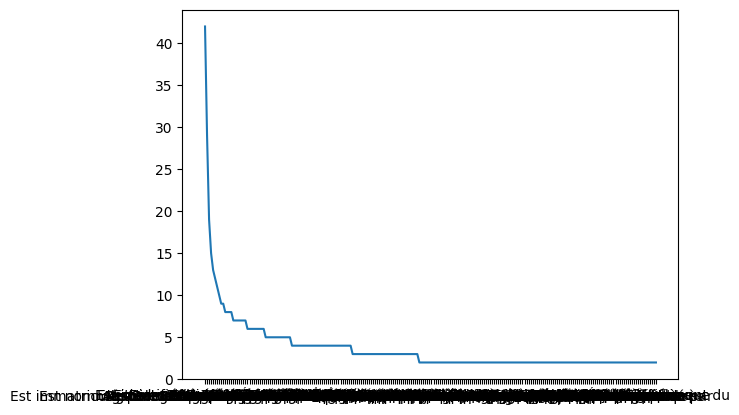

In [48]:
plt.plot(df["relation"].unique()[df["relation"].value_counts() >= 2], df["relation"].value_counts()[df["relation"].value_counts() >= 2])

(array([814.,  22.,   4.,   1.,   1.,   0.,   1.,   0.,   0.,   1.]),
 array([ 1. ,  5.1,  9.2, 13.3, 17.4, 21.5, 25.6, 29.7, 33.8, 37.9, 42. ]),
 <BarContainer object of 10 artists>)

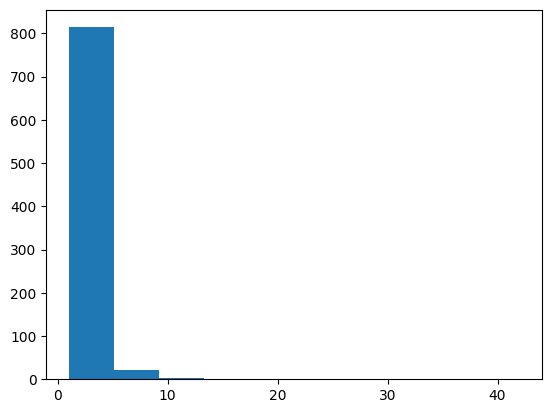

In [49]:
plt.hist(df["relation"].value_counts())

In [50]:
df["relation"].value_counts().index[:20]

Index(['Déclare', 'Désigne', 'Concerne', 'Comporte', 'Est', 'Inclut',
       'Informe', 'Révèle', 'S'engage à', 'Comprend', 'A', 'Correspondent à',
       'N'est pas situé dans', 'Peut demander', 'Déclare que', 'Garantit',
       'Possède surface', 'Agit en qualité de', 'Entraîne', 'Établi par'],
      dtype='object', name='relation')

In [51]:
pd.set_option("display.max_colwidth", None)  
pd.set_option("display.max_rows", None)

for i in range(10):
    display(df[df["relation"]==df["relation"].value_counts().index[i]])
pd.reset_option("display.max_colwidth")
pd.reset_option("display.max_rows")


,sujet,relation,objet
143,Promettant,Déclare,Avoir porté à la connaissance du bénéficiaire l’ensemble des informations
145,Bénéficiaire,Déclare,Avoir rempli ses engagements
318,Le beneficiaire,Déclare,Utiliser la partie non louée du bien à usage commercial de supermarché à dominante alimentaire
331,Promettant,Déclare,Partie louée du bien à usage commercial
338,Beneficiaire,Déclare,Utiliser partie non louée du bien
500,Promettant,Déclare,Ne pas posséder l’original de la caution
502,Promettant,Déclare,Aucun état des lieux établi
505,Promettant,Déclare,Absence de litiges entre locataire et voisinage
518,Promettant,Déclare,Ne pas posséder l’original de la caution
520,Promettant,Déclare,Aucun état des lieux établi


,sujet,relation,objet
221,Acte de vente,Désigne,Acte authentique vente
222,Annexes,Désigne,Documents annexés aux présentes
223,Beneficiaire,Désigne,Société vivendi et compagnie
224,Bien,Désigne,Immeuble objet promesse vente situé à saint-etienne les iles 3 rue de la camaillaude
225,Conditions suspensives,Désigne,Conditions suspensives consentement promesse
226,Dossier d’informations,Désigne,Ensemble documents relatifs bien possédés promettant
239,Acte de vente,Désigne,Acte authentique de vente à recevoir par notaire
243,Bénéficiaire,Désigne,Société vivendi et compagnie
244,Bien,Désigne,Immeuble situé à saint-etienne (loire
246,Dossier d’informations,Désigne,Ensemble documents relatifs au bien possédé par promettant


,sujet,relation,objet
606,Interdiction,Concerne,Bien objet des présentes
651,Activité de prestation et vente,Concerne,Articles et produits de sport et loisirs
879,Déclaration préalable façades,Concerne,Réfection des façades pour enseignes zodio et renault
887,Demande d’autorisation de travaux,Concerne,Aménagement de deux cellules commerciales
954,Permis de construire d’équipement commercial,Concerne,Surface entre 300 et 1000 m²
983,Obligation accessibilité,Concerne,Circulations
984,Obligation accessibilité,Concerne,Places stationnement automobile
985,Obligation accessibilité,Concerne,Ascenseurs
986,Obligation accessibilité,Concerne,Locaux et équipements
1002,Plomb,Concerne,Immeuble habitation permis construire antérieur 1er janvier 1949


,sujet,relation,objet
304,Immeuble,Comporte,270 emplacements de stationnement
543,Décompte trésorerie,Comporte,Montant provisions sur charges versées depuis 1er janvier
544,Décompte trésorerie,Comporte,Montant charges payées à la même date
558,Décompte,Comporte,Provisions sur charges versées par locataires
559,Décompte,Comporte,Montant charges payées
906,Panneau,Comporte,Identité bénéficiaire
907,Panneau,Comporte,Date permis
908,Panneau,Comporte,Numéro permis
909,Panneau,Comporte,Nature projet
910,Panneau,Comporte,Superficie terrain


,sujet,relation,objet
53,Genepoint france,Est,Société anonyme
61,Carrefour,Est,Société à responsabilité limitée
88,Promettant,Est,Société de droit français
96,Beneficiaire,Est,Société de droit français
146,Devoir d’information,Est,Réciproque
603,Carrefour,Est,Future utilisatrice du bâtiment
1081,Mérule,Est,Champignon obscurité bois humide
1125,Radon,Est,Gaz radioactif d'origine naturelle
1217,Basias,Est,Base données anciens sites industriels et activités service
1218,Basol,Est,Base données sites et sols pollués


,sujet,relation,objet
251,Dossier d’informations,Inclut,Documentation annexée
354,Versement,Inclut,Provision sur frais d’acte de vente et prêt éventuel
570,Le prix,Inclut,Tva au taux de 20 %
945,Surface de vente,Inclut,Espaces affectés à circulation clientèle
946,Surface de vente,Inclut,Exposition de marchandises
947,Surface de vente,Inclut,Paiement des marchandises
948,Surface de vente,Inclut,Circulation du personnel
1107,Parcours travaux,Inclut,Premiere etape atteignant classe e au 1er janvier 2028
1108,Parcours travaux,Inclut,Etape intermediaire atteignant classe c
1109,Parcours travaux,Inclut,Etape finale atteignant classe b


,sujet,relation,objet
314,La société renault france,Informe,Le promettant de sa volonté de réduire la surface louée
333,Renault france,Informe,Promettant de volonté réduire surface louée directement
347,Rédacteur,Informe,Parties que signature privée ne permet pas publier acte
902,Notaire,Informe,Bénéficiaire
1231,Notaire soussigné,Informe,Les parties des dispositions de l’article l.514-20 du code de l’environnement
1239,Notaire soussigné,Informe,Parties
1271,Notaire soussigné,Informe,Parties sur dispositions article l 541-2 code de l’environnement
1274,Notaire soussigné,Informe,Parties
1326,Bénéficiaire,Informe,Promettant quinze jours avant signature acte vente
1378,Notaire,Informe,Bénéficiaire que la publication d'une promesse de vente synallagmatique rend l'acte opposable aux tiers


,sujet,relation,objet
676,État hypothécaire,Révèle,Origine propriété trentenaire et régulière
855,Certificat d'urbanisme,Révèle,Dispositions d'urbanisme applicables
856,Certificat d'urbanisme,Révèle,Servitudes d'utilité publique
857,Certificat d'urbanisme,Révèle,Droit de préemption
858,Certificat d'urbanisme,Révèle,Régime des taxes et participations d'urbanisme
860,Certificat d'urbanisme,Révèle,Existence d'un emplacement réservé
1034,Rapport,Révèle,Présence d’amiante dans matériaux et produits des listes a ou b
1036,Rapport,Révèle,Matériaux et produits listes a ou b contiennent amiante
1119,Diagnostic,Révèle,Consommation énergétique 151 kwhep/m².an
1120,Diagnostic,Révèle,Émissions de gaz à effet de serre 4 kg éqco2/m².an


,sujet,relation,objet
766,Acquéreur,S'engage à,Établir une clôture défensive à la nouvelle limite d'emprise du domaine ferroviaire dans un délai de six mois
1345,Promettant,S'engage à,Ne pas apporter de modification en dehors des travaux prévus par l’avenant cartio
1346,Promettant,S'engage à,Délivrer le bien dans son état actuel
1347,Promettant,S'engage à,Conserver ses assurances
1348,Promettant,S'engage à,Maintenir en bon état les équipements du bien
1349,Promettant,S'engage à,Laisser les fils électriques d'éclairage suffisamment longs et équipés
1350,Promettant,S'engage à,Entretenir le bien et ses abords
1351,Promettant,S'engage à,Mettre hors-gel les installations en saison froide
1352,Promettant,S'engage à,Réparer les dégâts survenus depuis la visite


,sujet,relation,objet
286,Immeuble,Comprend,270 emplacements de stationnement
756,Ensemble des lots de la zac des iles,Comprend,Servitude de passage de tous usages
786,Fonds servant,Comprend,Parcelle 1146
788,Fonds servant,Comprend,Parcelle 1147
790,Fonds servant,Comprend,Parcelle 1130
792,Fonds servant,Comprend,Parcelle 1151
794,Fonds dominant,Comprend,Parcelle 1134
796,Fonds dominant,Comprend,Parcelle 1136
798,Fonds dominant,Comprend,Parcelle 1138


#### Sujets

In [78]:
(df["sujet"].value_counts() >= 2).sum()

np.int64(202)

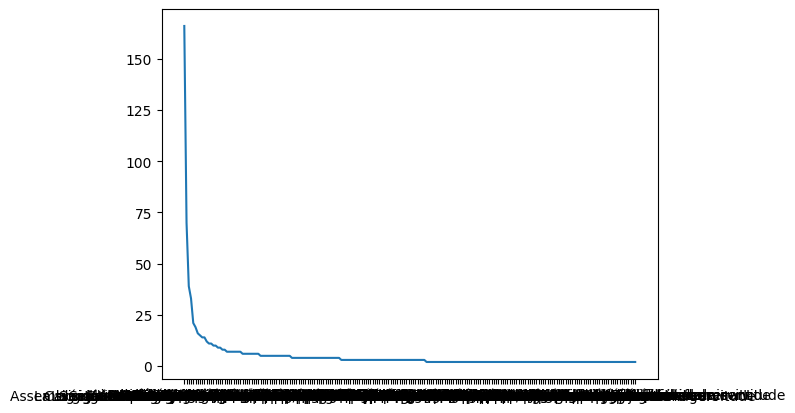

In [53]:
plt.plot(df["sujet"].unique()[df["sujet"].value_counts() >= 2], df["sujet"].value_counts()[df["sujet"].value_counts() >= 2])

(array([588.,   3.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([  1. ,  17.5,  34. ,  50.5,  67. ,  83.5, 100. , 116.5, 133. ,
        149.5, 166. ]),
 <BarContainer object of 10 artists>)

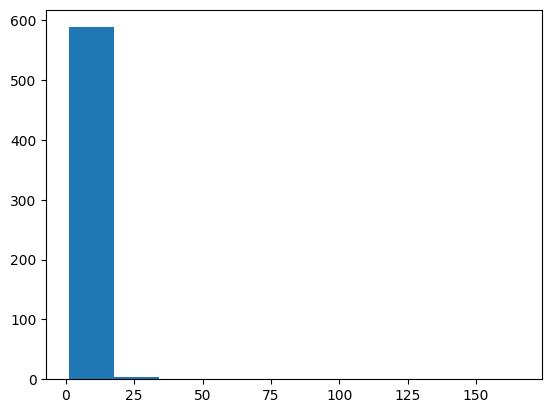

In [54]:
plt.hist(df["sujet"].value_counts())

In [55]:
df["sujet"].value_counts().index[:20]

Index(['Promettant', 'Beneficiaire', 'Parties', 'Bénéficiaire', 'Immeuble',
       'Genepoint france', 'Le bénéficiaire', 'Les parties',
       'Vivendi et compagnie', 'Bien', 'Acte', 'Le beneficiaire', 'Personnes',
       'Acte de vente', 'Maître alfred fillon', 'Notaire soussigné', 'Panneau',
       'Carrefour', 'L'immobiliere genepoint france', 'Diagnostic'],
      dtype='object', name='sujet')

In [56]:
pd.set_option("display.max_colwidth", None)  
pd.set_option("display.max_rows", None)

for i in range(10):
    display(df[df["sujet"]==df["sujet"].value_counts().index[i]])
pd.reset_option("display.max_colwidth")
pd.reset_option("display.max_rows")


,sujet,relation,objet
72,Promettant,Est constituée,Société de droit français
74,Promettant,N’est pas soumis à,Mesures de redressement judiciaire et nomination judiciaire
75,Promettant,N’est pas concerné par,Demande en nullité ou en dissolution
77,Promettant,A obtenu,Consentements des organes sociaux et autorités administratives compétentes
88,Promettant,Est,Société de droit français
89,Promettant,Présente,Caractéristiques exactes et à jour dans l’acte de vente
90,Promettant,N’est pas soumis à,Redressement judiciaire
91,Promettant,N’est pas concerné par,Demande en nullité
92,Promettant,N’est pas concerné par,Demande en dissolution
143,Promettant,Déclare,Avoir porté à la connaissance du bénéficiaire l’ensemble des informations


,sujet,relation,objet
79,Beneficiaire,Est constituée,Société de droit français
81,Beneficiaire,N’est pas soumis à,Mesures de redressement judiciaire et nomination judiciaire
82,Beneficiaire,N’est pas concerné par,Demande en nullité ou en dissolution
84,Beneficiaire,A obtenu,Consentements des organes sociaux et autorités administratives compétentes
96,Beneficiaire,Est,Société de droit français
97,Beneficiaire,Présente,Caractéristiques exactes et à jour dans l’acte
98,Beneficiaire,N’est pas soumis à,Redressement judiciaire
99,Beneficiaire,N’est pas concerné par,Demande en nullité
100,Beneficiaire,N’est pas concerné par,Demande en dissolution
220,Beneficiaire,Accepte,Promesse unilatérale vente


,sujet,relation,objet
141,Parties,Déclarent,Que dispositions du contrat ont été négociées de bonne foi
149,Parties,Attestent,Que informations déterminantes sont rapportées aux présentes
166,Parties,Attestent que,Informations déterminantes sont rapportées aux présentes
167,Parties,Rappellent,Pré-signature de la promesse
211,Parties,Déclare accepter,Assumer risque découlant changement circonstances imprévisibles
212,Parties,Renonce à demander,Remise en cause contrat
216,Parties,Déclarent avoir reçu,Informations déterminantes consentement
217,Parties,Se sont convenues de conclure,Promesse
229,Parties,Déclare accepter,Assumer risque lié changement circonstances imprévisibles
230,Parties,Renonce à,Demander remise en cause du contrat


,sujet,relation,objet
145,Bénéficiaire,Déclare,Avoir rempli ses engagements
152,Bénéficiaire,A été admis,À visiter le bien immobilier
164,Bénéficiaire,Déclare avoir rempli,Mêmes engagements
171,Bénéficiaire,A été admis à,Visiter le bien immobilier
238,Bénéficiaire,Accepte,Promesse unilatérale de vente
243,Bénéficiaire,Désigne,Société vivendi et compagnie
427,Bénéficiaire,Accepte,Promesse
537,Bénéficiaire,Subrogé,Bénéfice loyers
538,Bénéficiaire,Bénéficiera,Action recouvrement
552,Bénéficiaire,Subrogé dans,Bénéfice loyers


,sujet,relation,objet
280,Immeuble,Situé,3 rue de la camaillaude à saint-etienne (loire
281,Immeuble,Usage,Commercial
282,Immeuble,Surface totale,7989 m²
283,Immeuble,Divisé en,Deux cellules
286,Immeuble,Comprend,270 emplacements de stationnement
298,Immeuble,Usage,Commercial
299,Immeuble,Situé à,3 rue de la camaillaude – saint-étienne (loire
300,Immeuble,Possède,Surface de plancher totale de 7989 m²
301,Immeuble,Divisé en,Deux cellules
304,Immeuble,Comporte,270 emplacements de stationnement


,sujet,relation,objet
7,Genepoint france,A pour siège,Kremlin-bicetre (94270
8,Genepoint france,Est identifié sous le numéro,123432942
9,Genepoint france,Est immatriculé au registre du commerce et des sociétés de,Paris metropole
16,Genepoint france,Est représenté par,Madame simone michelin
22,Genepoint france,A son siège à,Kremlin-bicetre (94270
23,Genepoint france,Est identifié sous,Siren 123432942
24,Genepoint france,Est immatriculée au,Registre du commerce et des sociétés de paris metropole
31,Genepoint france,Est représentée par,Madame simone michelin
35,Genepoint france,A siège social à,Kremlin-bicetre rue herthe
36,Genepoint france,Est immatriculée au,Registre du commerce et des sociétés de paris metropole


,sujet,relation,objet
175,Le bénéficiaire,A été admis à visiter,Le bien immobilier
176,Le bénéficiaire,A effectué,Visites nécessaires
177,Le bénéficiaire,A été éventuellement accompagné de,Ses conseils
181,Le bénéficiaire,Déclare être,Investisseur averti dans l’immobilier
182,Le bénéficiaire,A procédé à,Analyse du dossier d’informations
183,Le bénéficiaire,A réalisé,Visites de l’immeuble
185,Le bénéficiaire,Apprécie,Situation juridique technique fiscale locative environnementale et administrative de l’immeuble
195,Le bénéficiaire,A été admis à visiter,Le bien immobilier
196,Le bénéficiaire,A effectué,Toutes les visites nécessaires
197,Le bénéficiaire,A été accompagné de,Ses conseils


,sujet,relation,objet
186,Les parties,Conviennent que,Le dossier d’informations sera complété
189,Les parties,Déclarent que,Négociations précédant la signature ont été menées de bonne foi
205,Les parties,Conviennent que,Le dossier d’informations sera complété pendant la période intermédiaire
208,Les parties,Affirment que,Le contrat reflète l’équilibre voulu par chacune
209,Les parties,Déclarent avoir été averties par,Le notaire des dispositions de l’article 1195 du code civil
210,Les parties,Acceptent,Le risque de changement de circonstances imprévisibles
313,Les parties,Déclarent,Que la promesse ne comprend ni meubles ni objets mobiliers
323,Les parties,Conviennent,D’établir les présentes sous forme de promesse unilatérale
325,Les parties,Sont informées,Que la signature privée ne permet pas publier un acte au service de la publicité foncière
326,Les parties,Opèrent,Le choix de conclure un acte authentique


,sujet,relation,objet
10,Vivendi et compagnie,A pour siège,Epinay-sur-seine (93800
11,Vivendi et compagnie,Est identifié au siren sous le numéro,787921338
12,Vivendi et compagnie,Est immatriculé au registre du commerce et des sociétés de,Villejuif
25,Vivendi et compagnie,A son siège à,Epinay-sur-seine (93800
26,Vivendi et compagnie,Est identifié sous,Siren 787921338
27,Vivendi et compagnie,Est immatriculée au,Registre du commerce et des sociétés de villejuif
39,Vivendi et compagnie,Est représentée par,Madame charlène mochico
58,Vivendi et compagnie,Est représentée par,Madame charlène mochico
66,Vivendi et compagnie,Nommée par,Assemblée générale extraordinaire le 30 décembre 2005
67,Vivendi et compagnie,Reconduite en fonctions par,Décision de l’assemblée générale ordinaire le 29 mai 2015


,sujet,relation,objet
224,Bien,Désigne,Immeuble objet promesse vente situé à saint-etienne les iles 3 rue de la camaillaude
244,Bien,Désigne,Immeuble situé à saint-etienne (loire
290,Bien,Constitue,Lot 15 de la zone d’aménagement concerté « zac les iles »
466,Bien,Doit être,Entièrement libéré d’occupants
469,Bien,Est partiellement loué à,Renault france
471,Bien,Est destiné à,Usage commercial
486,Bien,Est partiellement loué au profit de,Société renault france
1028,Bien,N’entre pas dans,Champ d’application des articles l1334-5 et suivants du code de la santé publique
1074,Bien,Déclaré non infesté par,Termites
1076,Bien,N’est pas infesté par,Termites


#### Objet

In [79]:
(df["objet"].value_counts() >= 2).sum()

np.int64(132)

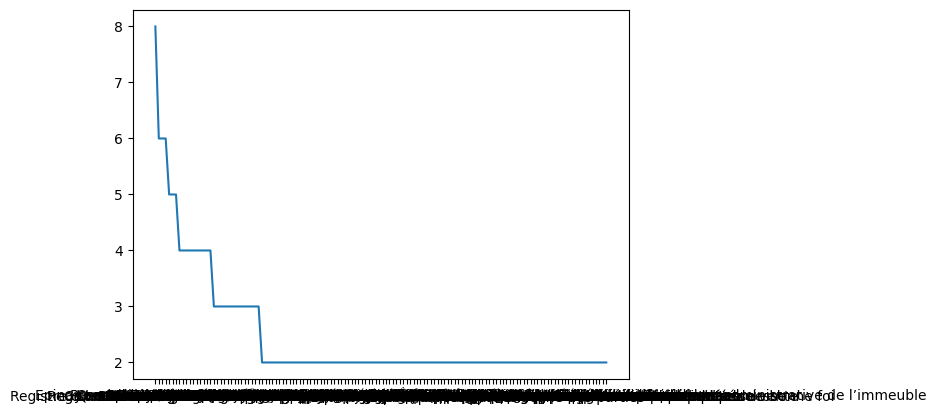

In [80]:
plt.plot(df["objet"].unique()[df["objet"].value_counts() >= 2], df["objet"].value_counts()[df["objet"].value_counts() >= 2])

(array([1.119e+03, 1.010e+02, 1.400e+01, 0.000e+00, 1.000e+01, 3.000e+00,
        0.000e+00, 3.000e+00, 0.000e+00, 1.000e+00]),
 array([1. , 1.7, 2.4, 3.1, 3.8, 4.5, 5.2, 5.9, 6.6, 7.3, 8. ]),
 <BarContainer object of 10 artists>)

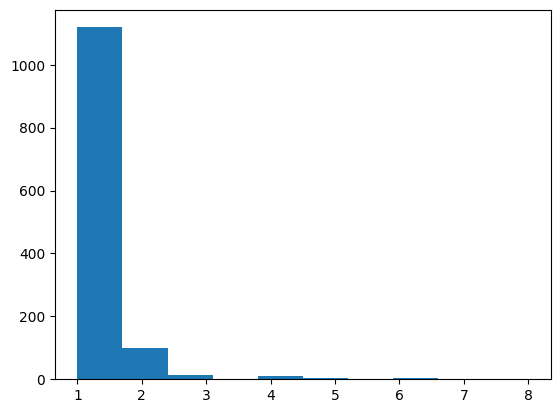

In [59]:
plt.hist(df["objet"].value_counts())

In [60]:
df["objet"].value_counts().index[:10]

Index(['Bien', 'Promesse', 'Promettant', 'Beneficiaire', 'Parties',
       'Pleine propriété du bien', 'Le bénéficiaire',
       'Contrat ou engagement important', 'Société de droit français',
       'Bénéficiaire'],
      dtype='object', name='objet')

In [61]:
pd.set_option("display.max_colwidth", None)  
pd.set_option("display.max_rows", None)

for i in range(10):
    display(df[df["objet"]==df["objet"].value_counts().index[i]])
pd.reset_option("display.max_colwidth")
pd.reset_option("display.max_rows")


,sujet,relation,objet
369,Promettant,Dispose librement du,Bien
392,Le promettant,Disposera librement,Bien
408,Promettant,Dispose de,Bien
656,Droit de préemption,Ne peut être exercé sur,Bien
657,Droit de préférence,Ne peut être exercé sur,Bien
1173,Extrait document graphique,Situe,Bien
1174,Extrait règlement,Concerne,Bien
1255,Secteur information sols,N'existe pas pour,Bien


,sujet,relation,objet
217,Parties,Se sont convenues de conclure,Promesse
218,Conventions,Font partie intégrante de,Promesse
236,Conventions présentes,Font partie intégrante,Promesse
427,Bénéficiaire,Accepte,Promesse
447,Beneficiaire,Accepte,Promesse
448,Promettant,Fait,Promesse


,sujet,relation,objet
5,Maître alfred fillon,Assiste,Promettant
362,Maître alfred fillon,Assiste,Promettant
383,Maître alfred fillon,Assiste,Promettant
846,Bénéficiaire,Confère mandat à,Promettant
1331,Bénéficiaire,Reste débiteur solidaire avec substitué,Promettant
1332,Avant‑contrat,Oblige,Promettant


,sujet,relation,objet
219,Promettant,Confère faculté d’acquérir,Beneficiaire
350,Levée d'option,Effectuée par,Beneficiaire
497,Caution bancaire,Ne pourra profiter à,Beneficiaire
501,Caution bancaire,Ne profite pas,Beneficiaire
519,Caution bancaire,Ne pourra profiter,Beneficiaire
671,Condition suspensive droit commun,Est stipulée en faveur de,Beneficiaire


,sujet,relation,objet
117,Engagements souscrits et déclarations,Émanent directement de,Parties
136,Engagements et déclarations,Émanent de,Parties
157,Engagements souscrits et déclarations faites,Sont indiqués comme émanant de,Parties
1239,Notaire soussigné,Informe,Parties
1274,Notaire soussigné,Informe,Parties


,sujet,relation,objet
69,Genepoint france,Vend,Pleine propriété du bien
70,Genepoint france,Vend,Pleine propriété du bien
71,Vivendi et compagnie,Fera l'acquisition de,Pleine propriété du bien
86,Genepoint france,Vend,Pleine propriété du bien
87,Vivendi et compagnie,Acquiert,Pleine propriété du bien


,sujet,relation,objet
184,Les documents du dossier d’informations,Satisfont,Le bénéficiaire
204,Les documents du dossier d’informations,Satisfont,Le bénéficiaire
254,Indemnité d’immobilisation,Est due par,Le bénéficiaire
265,Frais,Supporté par,Le bénéficiaire
266,Indemnité d’immobilisation,Est due par,Le bénéficiaire


,sujet,relation,objet
78,La signature et l’exécution de la vente par le promettant,Ne contreviennent pas à,Contrat ou engagement important
85,La signature et l’exécution de l’acte par le beneficiaire,Ne contreviennent pas à,Contrat ou engagement important
95,Signature et exécution de la vente par le promettant,Ne contreviennent pas,Contrat ou engagement important
103,Signature et exécution de l’acte par le beneficiaire,Ne contreviennent pas,Contrat ou engagement important


,sujet,relation,objet
72,Promettant,Est constituée,Société de droit français
79,Beneficiaire,Est constituée,Société de droit français
88,Promettant,Est,Société de droit français
96,Beneficiaire,Est,Société de droit français


,sujet,relation,objet
898,Promettant,Subrogera,Bénéficiaire
902,Notaire,Informe,Bénéficiaire
1172,État,Remis à,Bénéficiaire
1327,Sommes avancées,Ne seront pas restituées,Bénéficiaire


### Avec ontologie

In [224]:
# Lecture et parsing du fichier JSON
with open("triplets_francais_ontologiques.json", "r", encoding="utf-8") as f:
    triplets = json.load(f)

# Affichage
for sujet, label, relation, objet in triplets:
    print(f"Sujet: {sujet}, Label: {label} Relation: {relation}, Objet: {objet}")


Sujet: PROMESSE UNILATERALE DE VENTE, Label: CONTRAT Relation: SIGNED_AT, Objet: Paris
Sujet: PROMESSE UNILATERALE DE VENTE, Label: CONTRAT Relation: SIGNED_ON, Objet: 21 Juin 2024
Sujet: Laura SIMON, Label: PERSONNE Relation: WORKS_AT, Objet: CERCLUSE Notaires Paris
Sujet: Alfred FILLON, Label: PERSONNE Relation: PART_OF, Objet: Genepoint FRANCE
Sujet: Genepoint FRANCE, Label: ENTREPRISE Relation: SIGNED, Objet: PROMESSE UNILATERALE DE VENTE
Sujet: VIVENDI ET COMPAGNIE, Label: BENEFICIAIRE Relation: SIGNED, Objet: PROMESSE UNILATERALE DE VENTE
Sujet: L'IMMOBILIERE Genepoint FRANCE, Label: ENTREPRISE Relation: PART_OF, Objet: Genepoint FRANCE
Sujet: Simone MICHELIN, Label: PERSONNE Relation: WORKS_AT, Objet: Genepoint FRANCE
Sujet: Agathe GEKITE, Label: PERSONNE Relation: ACCORDED, Objet: Simone MICHELIN
Sujet: Agathe GEKITE, Label: PERSONNE Relation: WORKS_AT, Objet: Genepoint FRANCE
Sujet: Agathe GEKITE, Label: PERSONNE Relation: WORKS_AT, Objet: Genepoint FRANCE
Sujet: Charlène MOCH

In [225]:
data = []

for sujet, label, relation, objet in triplets:
    sujet_norm = normaliser_texte(sujet)
    objet_norm = normaliser_texte(objet)
    data.append({
        "sujet": sujet,
        "sujet_norm": sujet_norm,
        "entity": label,
        "relation": relation,
        "objet": objet,
        "objet_norm": objet_norm
    })

df = pd.DataFrame(data).drop_duplicates()
df


,sujet,sujet_norm,entity,relation,objet,objet_norm
0,PROMESSE UNILATERALE DE VENTE,promesse unilaterale vente,CONTRAT,SIGNED_AT,Paris,paris
1,PROMESSE UNILATERALE DE VENTE,promesse unilaterale vente,CONTRAT,SIGNED_ON,21 Juin 2024,21 juin 2024
2,Laura SIMON,laura simon,PERSONNE,WORKS_AT,CERCLUSE Notaires Paris,cercluse notaires paris
3,Alfred FILLON,alfred fillon,PERSONNE,PART_OF,Genepoint FRANCE,genepoint france
4,Genepoint FRANCE,genepoint france,ENTREPRISE,SIGNED,PROMESSE UNILATERALE DE VENTE,promesse unilaterale vente
...,...,...,...,...,...,...
343,Mme MOCHICO Charlène,mme mochico charlene,PERSONNE,SIGNED_ON,21 juin 2024,21 juin 2024
344,Mme MOCHICO Charlène,mme mochico charlene,PERSONNE,SIGNED_AT,PARIS,paris
345,Me CARTIER LAURE,me cartier laure,PERSONNE,SIGNED_ON,21 juin 2024,21 juin 2024
346,Me CARTIER LAURE,me cartier laure,PERSONNE,SIGNED_AT,PARIS,paris


#### Relations

In [226]:
(df["relation"].value_counts() >= 2).sum()

np.int64(8)

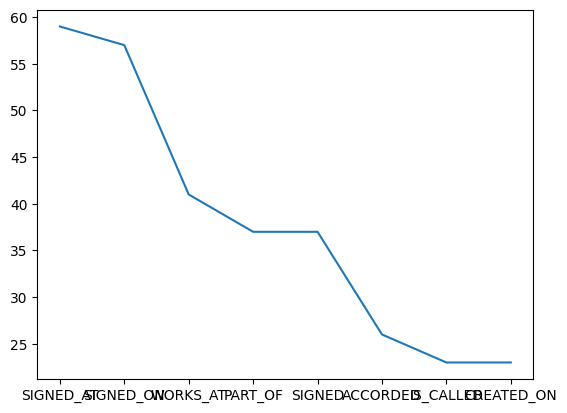

In [227]:
plt.plot(df["relation"].unique()[df["relation"].value_counts() >= 2], df["relation"].value_counts()[df["relation"].value_counts() >= 2])

(array([3., 0., 0., 2., 0., 1., 0., 0., 0., 2.]),
 array([23. , 26.6, 30.2, 33.8, 37.4, 41. , 44.6, 48.2, 51.8, 55.4, 59. ]),
 <BarContainer object of 10 artists>)

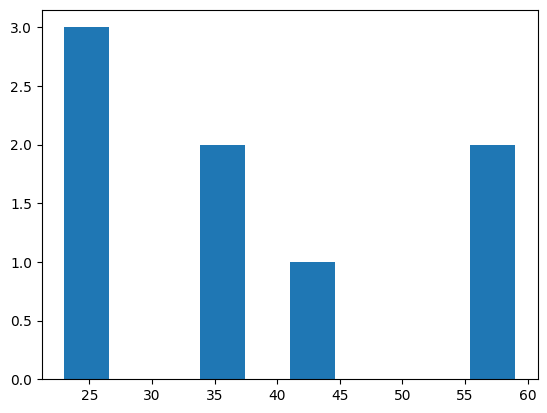

In [228]:
plt.hist(df["relation"].value_counts())

In [229]:
df["relation"].value_counts().index[:10]

Index(['SIGNED_ON', 'SIGNED', 'PART_OF', 'SIGNED_AT', 'ACCORDED', 'CREATED_ON',
       'WORKS_AT', 'IS_CALLED'],
      dtype='object', name='relation')

In [230]:
display(df[df["relation"]==df["relation"].value_counts().index[0]])


,sujet,sujet_norm,entity,relation,objet,objet_norm
1,PROMESSE UNILATERALE DE VENTE,promesse unilaterale vente,CONTRAT,SIGNED_ON,21 Juin 2024,21 juin 2024
24,contrat.txt,contrattxt,CONTRAT,SIGNED_ON,Date de la Promesse,date promesse
28,Promesse,promesse,CONTRAT,SIGNED_ON,Date de la Promesse,date promesse
41,Acte de Vente,acte vente,CONTRAT,SIGNED_ON,Date de Signature de l’Acte de Vente,date signature lacte vente
49,BENEFICIAIRE,beneficiaire,BENEFICIAIRE,SIGNED_ON,20 juin 2024,20 juin 2024
...,...,...,...,...,...,...
331,M. Julie DUPONT,m julie dupont,PERSONNE,SIGNED_ON,21 juin 2024,21 juin 2024
333,Mme Simone MICHELIN,mme simone michelin,PERSONNE,SIGNED_ON,21 juin 2024,21 juin 2024
341,Me FILLON Alfred,me fillon alfred,PERSONNE,SIGNED_ON,21 juin 2024,21 juin 2024
343,Mme MOCHICO Charlène,mme mochico charlene,PERSONNE,SIGNED_ON,21 juin 2024,21 juin 2024


#### Sujets

In [231]:
(df["sujet_norm"].value_counts() >= 2).sum()

np.int64(50)

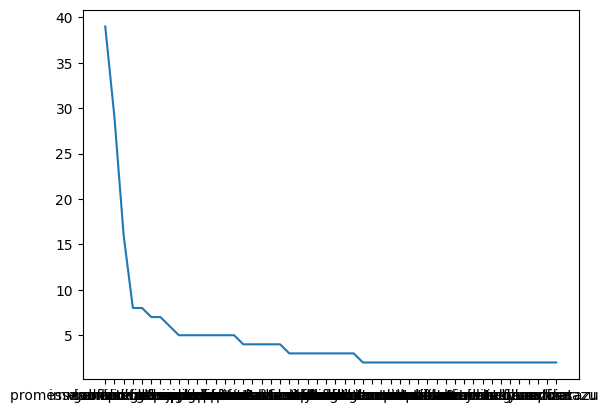

In [232]:
plt.plot(df["sujet_norm"].unique()[df["sujet_norm"].value_counts() >= 2], df["sujet_norm"].value_counts()[df["sujet_norm"].value_counts() >= 2])

(array([95., 12.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  1.]),
 array([ 1. ,  4.8,  8.6, 12.4, 16.2, 20. , 23.8, 27.6, 31.4, 35.2, 39. ]),
 <BarContainer object of 10 artists>)

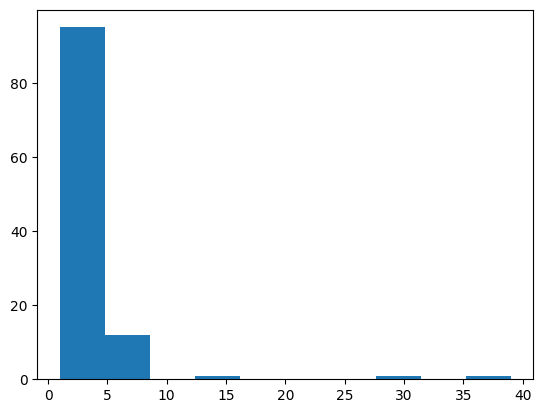

In [233]:
plt.hist(df["sujet_norm"].value_counts())

In [234]:
df["sujet_norm"].value_counts().index[:10]

Index(['promettant', 'beneficiaire', 'contrattxt', 'promesse vente',
       'acte vente', 'contrat', 'chocobon', 'sadi', 'notaire soussigne',
       'renault france'],
      dtype='object', name='sujet_norm')

In [235]:
display(df[df["sujet_norm"]==df["sujet_norm"].value_counts().index[0]])


,sujet,sujet_norm,entity,relation,objet,objet_norm
18,PROMETTANT,promettant,PROMETTANT,SIGNED,Acte de Vente,acte vente
22,PROMETTANT,promettant,PROMETTANT,SIGNED,contrat.txt,contrattxt
25,PROMETTANT,promettant,PROMETTANT,ACCORDED,BENEFICIAIRE,beneficiaire
27,Promettant,promettant,PROMETTANT,SIGNED,Promesse,promesse
30,Promettant,promettant,PROMETTANT,PART_OF,Promesse,promesse
...,...,...,...,...,...,...
298,PROMETTANT,promettant,PROMETTANT,SIGNED_ON,30 novembre 2001,30 novembre 2001
299,PROMETTANT,promettant,PROMETTANT,SIGNED_AT,LEVALLOIS-PERRET,levalloisperret
300,PROMETTANT,promettant,PROMETTANT,SIGNED_AT,PANTIN,pantin
301,PROMETTANT,promettant,PROMETTANT,SIGNED_AT,TOURS 2,tours 2


#### Objet

In [236]:
(df["objet_norm"].value_counts() >= 2).sum()

np.int64(54)

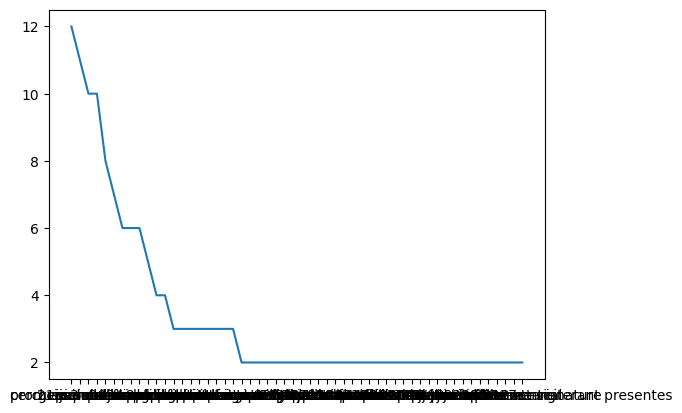

In [237]:
plt.plot(df["objet_norm"].unique()[df["objet_norm"].value_counts() >= 2], df["objet_norm"].value_counts()[df["objet_norm"].value_counts() >= 2])

(array([156.,   8.,   2.,   1.,   3.,   1.,   1.,   0.,   2.,   2.]),
 array([ 1. ,  2.1,  3.2,  4.3,  5.4,  6.5,  7.6,  8.7,  9.8, 10.9, 12. ]),
 <BarContainer object of 10 artists>)

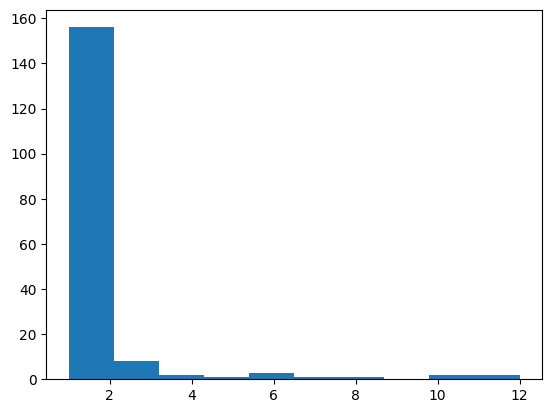

In [238]:
plt.hist(df["objet_norm"].value_counts())

In [239]:
df["objet_norm"].value_counts().index[:10]

Index(['acte vente', 'contrat', 'contrattxt', 'beneficiaire', 'promettant',
       'genepoint france', '21 juin 2024', 'acte authentique vente',
       'saintetienne', 'promesse vente'],
      dtype='object', name='objet_norm')

In [240]:
display(df[df["objet_norm"]==df["objet_norm"].value_counts().index[0]])

,sujet,sujet_norm,entity,relation,objet,objet_norm
18,PROMETTANT,promettant,PROMETTANT,SIGNED,Acte de Vente,acte vente
19,BENEFICIAIRE,beneficiaire,BENEFICIAIRE,SIGNED,Acte de Vente,acte vente
65,BENEFICIAIRE,beneficiaire,BENEFICIAIRE,SIGNED,acte de vente,acte vente
66,PROMETTANT,promettant,PROMETTANT,SIGNED,acte de vente,acte vente
74,BENEFICIAIRE,beneficiaire,BENEFICIAIRE,SIGNED_ON,Acte de Vente,acte vente
...,...,...,...,...,...,...
87,Bénéficiaire,beneficiaire,BENEFICIAIRE,SIGNED,Acte de Vente,acte vente
90,Beneficiaire,beneficiaire,BENEFICIAIRE,SIGNED,Acte de Vente,acte vente
146,S.A.D.I,sadi,ENTREPRISE,ACCORDED,Acte de vente,acte vente
147,Etablissements Genepoint,etablissements genepoint,ENTREPRISE,ACCORDED,Acte de vente,acte vente


## Brouillon: associer le triplet aux chunks


In [116]:
nodes = SimpleNodeParser().get_nodes_from_documents(documents)
print(f"{len(nodes)} nœuds extraits")

64 nœuds extraits


In [117]:
max_knowledge_triplets = 20
text = documents[0].text_resource.text
extract_prompt = [
    (
    "Un texte est fourni ci-dessous. À partir de ce texte, extraire les triplets de connaissance en te basant sur le schema fourni. "
    "Essaie de limiter l'output à maximum {max_knowledge_triplets} triplets extraits par noeud.\n"
    "Toutes les relations doivent être en français"
    "-------\n"
    f"Text: {nodes[i].get_content()}\n"
    "Triplets:\n"
) for i in range(len(nodes))]

# best practice to use upper-case
entities = Literal["PERSON", "PLACE", "ORGANIZATION"]
relations = Literal["HAS", "PART_OF", "WORKED_ON", "WORKED_WITH", "WORKED_AT"]

entities = Literal["ENTREPRISE", "PERSONNE", "CONTRAT", "BENEFICIAIRE", "PROMETTANT", "DATE", "LOCATION"]
relations = Literal["WORKS_AT", "PART_OF", "ACCORDED", "IS_CALLED", "CREATED_ON", "SIGNED", "SIGNED_ON", "SIGNED_AT"]

# define which entities can have which relations
validation_schema = [
    ["PERSONNE", "WORKS_AT", "ENTREPRISE"],
    ["PROMETTANT", "IS_CALLED", "ENTREPRISE"],
    ["BENEFICIAIRE", "IS_CALLED", "ENTREPRISE"],
    ["PERSONNE", "SIGNED", "CONTRAT"],
    ["CONTRAT", "SIGNED_ON", "DATE"],
    ["CONTRAT", "SIGNED_AT", "LOCATION"],
    ["ENTREPRISE", "CREATED_ON", "DATE"],
]


res = []
cpt = 0

for i in range(len(nodes)):
    kg_extractor = SchemaLLMPathExtractor(
    llm=llm, 
    max_triplets_per_chunk=max_knowledge_triplets, 
    num_workers=4, 
    extract_prompt=extract_prompt[i],
    possible_relations=relations,
    kg_validation_schema=validation_schema,
    strict=False
    )
    l = kg_extractor([nodes[i]])
    print("les triplets sont sortis")
    res = res + l
    cpt += 1
    print(cpt)

les triplets sont sortis
1
les triplets sont sortis
2
les triplets sont sortis
3
les triplets sont sortis
4
les triplets sont sortis
5
les triplets sont sortis
6
les triplets sont sortis
7
les triplets sont sortis
8
les triplets sont sortis
9
les triplets sont sortis
10
les triplets sont sortis
11
les triplets sont sortis
12
les triplets sont sortis
13
les triplets sont sortis
14
les triplets sont sortis
15
les triplets sont sortis
16
les triplets sont sortis
17
les triplets sont sortis
18
les triplets sont sortis
19
les triplets sont sortis
20
les triplets sont sortis
21
les triplets sont sortis
22
les triplets sont sortis
23
les triplets sont sortis
24
les triplets sont sortis
25
les triplets sont sortis
26
les triplets sont sortis
27
les triplets sont sortis
28
les triplets sont sortis
29
les triplets sont sortis
30
les triplets sont sortis
31
les triplets sont sortis
32
les triplets sont sortis
33
les triplets sont sortis
34
les triplets sont sortis
35
les triplets sont sortis
36
l

In [118]:
cpt = 0
entities = []

for i in range(len(res)):
    nodes = res[i].metadata['nodes']
    for node in nodes:
        if (node.name in entities) == False:
            entities.append(node.name) 
            cpt += 1
            print(node.name)
        
print()
print(f"{cpt} entités ont été extraites")

Maître Laura SIMON
CERCLUSE Notaires Paris
Madame Simone MICHELIN
Genepoint FRANCE
Madame Agathe GEKITE
L'IMMOBILIERE Genepoint FRANCE
INTERVENANT
Acte notarié
21 juin 2024
Paris (8ème)
1er septembre 2023
Madame Charlène MOCHICO
VIVENDI ET COMPAGNIE
Monsieur Thomas IRNEL
CARREFOUR
Madame Julie DUPONT
Monsieur Pirmin FINNOT
BIEN
PROMETTANT
société de droit français dûment constituée et existant valablement
BENEFICIAIRE
Documents relatifs à la capacité et à la qualité des parties
Acte de Vente
Promesse de Vente
Les Parties
Contrat
leur dénomination ou leur qualité
Dossier d'Informations
BÉNÉFICIAIRE
Présentes
Bénéficiaire
visite du Bien Immobilier
investisseur averti dans le domaine de l’immobilier
Promesse
Promesse unilatérale de vente
Annexes
Vente
BIEN immobilier
Les Iles, 3 rue de la Camaillaude, SAINT-ETIENNE (LOIRE) (42100)
Condition(s) Suspensive(s)
les conditions suspensives fixées pour la validité de la promesse
Dossier d’Informations
l’ensemble des documents relatifs au Bien mi

In [119]:
cpt = 0
entities = []

for i in range(len(res)):
    relations = res[i].metadata['relations']
    for relation in relations:
        if (relation.label in entities) == False:
            entities.append(relation.label) 
            cpt += 1
            print(relation.label)
        
print()
print(f"{cpt} relations ont été extraites")

WORKS_AT
IS_CALLED
SIGNED_ON
SIGNED_AT
ACCORDED
CREATED_ON
TRAVAILLE_POUR
NOMMÉE_LE
FAIT_PARTIE_DE
VEND
ACQUIERT
DÉCLARE
PART_OF
SIGNED
GARANTIT_CONTRE_LE_RISQUE_D'ÉVICTION
EST_OBJET_D'UN_PACTE_DE_PRÉFÉRENCE_BÉNÉFICIANT_À
EST_SUBROGÉ_DANS_TOUS_DROITS_RELATIFS_À
EST_LOUÉ_CONFORMÉMENT_AU
EST_SOUS-LOUÉ_AU_PROFIT_DE
SONT_SOUMIS_À
N'EST_PAS_SITUÉ_DANS
EST_SITUÉ_DANS
A_ÉTÉ_DÉLIVRÉ_PAR
EST_RÉPERTORIÉ_PAR
SONT_RÉPERTORIÉS_PAR
EST_CONCERNÉ_PAR
SE_TROUVE_DANS
SIGNÉ

28 relations ont été extraites


In [120]:
cpt = 0
entities = []

for i in range(len(res)):
    triplets = res[i].metadata['relations']
    for triplet in triplets:
        entities.append((triplet.source_id, triplet.label, triplet.target_id))
        cpt += 1
        print(triplet.source_id, triplet.label, triplet.target_id)
print()
print(f"{cpt} triplets ont été extraits")

Maître Laura SIMON WORKS_AT CERCLUSE Notaires Paris
Madame Simone MICHELIN WORKS_AT Genepoint FRANCE
Madame Agathe GEKITE WORKS_AT Genepoint FRANCE
L'IMMOBILIERE Genepoint FRANCE IS_CALLED INTERVENANT
Acte notarié SIGNED_ON 21 juin 2024
Acte notarié SIGNED_AT Paris (8ème)
Madame Agathe GEKITE ACCORDED Madame Simone MICHELIN
Madame Agathe GEKITE CREATED_ON 1er septembre 2023
Madame Agathe GEKITE TRAVAILLE_POUR Genepoint FRANCE
Madame Agathe GEKITE NOMMÉE_LE 1er septembre 2023
Madame Charlène MOCHICO TRAVAILLE_POUR VIVENDI ET COMPAGNIE
Monsieur Thomas IRNEL TRAVAILLE_POUR CARREFOUR
CARREFOUR FAIT_PARTIE_DE VIVENDI ET COMPAGNIE
Madame Julie DUPONT TRAVAILLE_POUR L'IMMOBILIERE Genepoint FRANCE
Monsieur Pirmin FINNOT TRAVAILLE_POUR L'IMMOBILIERE Genepoint FRANCE
Genepoint FRANCE VEND BIEN
VIVENDI ET COMPAGNIE ACQUIERT BIEN
PROMETTANT DÉCLARE société de droit français dûment constituée et existant valablement
BENEFICIAIRE DÉCLARE société de droit français dûment constituée et existant valabl

In [121]:
labels = labels = defaultdict(list)

for i in range(len(res)):
    nodes = res[i].metadata['nodes']
    for node in nodes:
        labels[node.name]= node.label

In [122]:
labels

defaultdict(list,
            {'Maître Laura SIMON': 'PERSON',
             'CERCLUSE Notaires Paris': 'ORGANIZATION',
             'Madame Simone MICHELIN': 'PERSON',
             'Genepoint FRANCE': 'ORGANIZATION',
             'Madame Agathe GEKITE': 'PERSON',
             "L'IMMOBILIERE Genepoint FRANCE": 'ORGANIZATION',
             'INTERVENANT': 'CONCEPT',
             'Acte notarié': 'EVENT',
             '21 juin 2024': 'TIME',
             'Paris (8ème)': 'LOCATION',
             '1er septembre 2023': 'TIME',
             'Madame Charlène MOCHICO': 'PERSON',
             'VIVENDI ET COMPAGNIE': 'ORGANIZATION',
             'Monsieur Thomas IRNEL': 'PERSON',
             'CARREFOUR': 'ORGANIZATION',
             'Madame Julie DUPONT': 'PERSON',
             'Monsieur Pirmin FINNOT': 'PERSON',
             'BIEN': 'MISCELLANEOUS',
             'PROMETTANT': 'ORGANIZATION',
             'société de droit français dûment constituée et existant valablement': 'MISCELLANEOUS',
     

In [123]:
cpt = 0
entities = []

for i in range(len(res)):
    triplets = res[i].metadata['relations']
    for triplet in triplets:
        entities.append((triplet.source_id, labels[triplet.source_id], triplet.label, triplet.target_id))
        cpt += 1
        print(triplet.source_id, labels[triplet.source_id],triplet.label, triplet.target_id)
print()
print(f"{cpt} triplets ont été extraits")

Maître Laura SIMON PERSON WORKS_AT CERCLUSE Notaires Paris
Madame Simone MICHELIN PERSON WORKS_AT Genepoint FRANCE
Madame Agathe GEKITE PERSON WORKS_AT Genepoint FRANCE
L'IMMOBILIERE Genepoint FRANCE ORGANIZATION IS_CALLED INTERVENANT
Acte notarié EVENT SIGNED_ON 21 juin 2024
Acte notarié EVENT SIGNED_AT Paris (8ème)
Madame Agathe GEKITE PERSON ACCORDED Madame Simone MICHELIN
Madame Agathe GEKITE PERSON CREATED_ON 1er septembre 2023
Madame Agathe GEKITE PERSON TRAVAILLE_POUR Genepoint FRANCE
Madame Agathe GEKITE PERSON NOMMÉE_LE 1er septembre 2023
Madame Charlène MOCHICO PERSON TRAVAILLE_POUR VIVENDI ET COMPAGNIE
Monsieur Thomas IRNEL PERSON TRAVAILLE_POUR CARREFOUR
CARREFOUR ORGANIZATION FAIT_PARTIE_DE VIVENDI ET COMPAGNIE
Madame Julie DUPONT PERSON TRAVAILLE_POUR L'IMMOBILIERE Genepoint FRANCE
Monsieur Pirmin FINNOT PERSON TRAVAILLE_POUR L'IMMOBILIERE Genepoint FRANCE
Genepoint FRANCE ORGANIZATION VEND BIEN
VIVENDI ET COMPAGNIE ORGANIZATION ACQUIERT BIEN
PROMETTANT ORGANIZATION DÉCLA

In [124]:
triplets_json = json.dumps([list(entity) for entity in entities], indent=2)

# Écriture dans un fichier
with open("triplets_avec_chunks.json", "w", encoding="utf-8") as f:
    f.write(triplets_json)

In [19]:
# Lecture et parsing du fichier JSON
with open("triplets_francais_ontologiques_test.json", "r", encoding="utf-8") as f:
    triplets = json.load(f)

# Affichage
for sujet, sujet_entity, relation, objet_entity, objet in triplets:
    print(f"Sujet: {sujet}, Sujet_entity: {sujet_entity} Relation: {relation}, Objet_entity: {objet_entity}, Objet: {objet}")


Sujet: PROMESSE UNILATERALE DE VENTE, Sujet_entity: CONTRAT Relation: SIGNED_ON, Objet_entity: DATE, Objet: 21 juin 2024
Sujet: Genepoint FRANCE, Sujet_entity: ENTREPRISE Relation: SIGNED, Objet_entity: CONTRAT, Objet: PROMESSE UNILATERALE DE VENTE
Sujet: VIVENDI ET COMPAGNIE, Sujet_entity: BENEFICIAIRE Relation: SIGNED, Objet_entity: CONTRAT, Objet: PROMESSE UNILATERALE DE VENTE
Sujet: Laura SIMON, Sujet_entity: PERSONNE Relation: WORKS_AT, Objet_entity: ENTREPRISE, Objet: CERCLUSE Notaires Paris
Sujet: Alfred FILLON, Sujet_entity: PERSONNE Relation: WORKS_AT, Objet_entity: LOCATION, Objet: LEVALLOIS PERRET (92300)
Sujet: Simone MICHELIN, Sujet_entity: PERSONNE Relation: PART_OF, Objet_entity: ENTREPRISE, Objet: Genepoint FRANCE
Sujet: Agathe GEKITE, Sujet_entity: PERSONNE Relation: PART_OF, Objet_entity: ENTREPRISE, Objet: Genepoint FRANCE
Sujet: CERCLUSE Notaires Paris, Sujet_entity: ENTREPRISE Relation: SIGNED_AT, Objet_entity: LOCATION, Objet: Paris (8ème)
Sujet: Agathe GEKITE, Su

In [20]:
data = []

for sujet, sujet_entity, relation, objet_entity, objet in triplets:
    sujet_norm = normaliser_texte(sujet)
    objet_norm = normaliser_texte(objet)
    data.append({
        "sujet": sujet,
        "sujet_norm": sujet_norm,
        "sujet_entity": sujet_entity,
        "relation": relation,
        "objet_entity": objet_entity,
        "objet": objet,
        "objet_norm": objet_norm
    })

df = pd.DataFrame(data).drop_duplicates()
df



,sujet,sujet_norm,sujet_entity,relation,objet_entity,objet,objet_norm
0,PROMESSE UNILATERALE DE VENTE,promesse unilaterale vente,CONTRAT,SIGNED_ON,DATE,21 juin 2024,21 juin 2024
1,Genepoint FRANCE,genepoint france,ENTREPRISE,SIGNED,CONTRAT,PROMESSE UNILATERALE DE VENTE,promesse unilaterale vente
2,VIVENDI ET COMPAGNIE,vivendi et compagnie,BENEFICIAIRE,SIGNED,CONTRAT,PROMESSE UNILATERALE DE VENTE,promesse unilaterale vente
3,Laura SIMON,laura simon,PERSONNE,WORKS_AT,ENTREPRISE,CERCLUSE Notaires Paris,cercluse notaires paris
4,Alfred FILLON,alfred fillon,PERSONNE,WORKS_AT,LOCATION,LEVALLOIS PERRET (92300),levallois perret 92300
...,...,...,...,...,...,...,...
371,Me FILLON Alfred,me fillon alfred,PERSONNE,SIGNED_AT,LOCATION,En son office,en son office
372,Mme MOCHICO Charlène,mme mochico charlene,PERSONNE,SIGNED_ON,DATE,21 juin 2024,21 juin 2024
373,Mme MOCHICO Charlène,mme mochico charlene,PERSONNE,SIGNED_AT,LOCATION,PARIS,paris
374,Me CARTIER LAURE,me cartier laure,PERSONNE,SIGNED_ON,DATE,21 juin 2024,21 juin 2024


In [23]:
df[["sujet_entity", "sujet_entity", "objet_entity"]].drop_duplicates().shape

(36, 3)

In [ ]:
# Output de res[1]
# TextNode(
#     id_='4e410116-352b-4b86-a540-150ce7585304',
#     embedding=None,
#     metadata={
#         'file_path': 'contrat.txt',
#         'file_name': 'contrat.txt',
#         'file_type': 'text/plain',
#         'file_size': 199284,
#         'creation_date': '2025-05-20',
#         'last_modified_date': '2025-05-16',
#         'nodes': [
#             EntityNode(
#                 label='PERSONNE',
#                 embedding=None,
#                 properties={
#                     'file_path': 'contrat.txt',
#                     'file_name': 'contrat.txt',
#                     'file_type': 'text/plain',
#                     'file_size': 199284,
#                     'creation_date': '2025-05-20',
#                     'last_modified_date': '2025-05-16'
#                 },
#                 name='Agathe GEKITE'
#             ),
#             EntityNode(
#                 label='ENTREPRISE',
#                 embedding=None,
#                 properties={...},
#                 name='Genepoint FRANCE'
#             ),
#             EntityNode(
#                 label='PERSONNE',
#                 embedding=None,
#                 properties={...},
#                 name='Charlène MOCHICO'
#             ),
#             EntityNode(
#                 label='ENTREPRISE',
#                 embedding=None,
#                 properties={...},
#                 name='VIVENDI ET COMPAGNIE'
#             ),
#             EntityNode(
#                 label='PERSONNE',
#                 embedding=None,
#                 properties={...},
#                 name='Thomas IRNEL'
#             ),
#             EntityNode(
#                 label='PERSONNE',
#                 embedding=None,
#                 properties={...},
#                 name='Charlène MOCHICO'
#             ),
#             EntityNode(
#                 label='PERSONNE',
#                 embedding=None,
#                 properties={...},
#                 name='Thomas IRNEL'
#             ),
#             EntityNode(
#                 label='ENTREPRISE',
#                 embedding=None,
#                 properties={...},
#                 name='CARREFOUR'
#             ),
#             EntityNode(
#                 label='PERSONNE',
#                 embedding=None,
#                 properties={...},
#                 name='Pirmin FINNOT'
#             ),
#             EntityNode(
#                 label='PERSONNE',
#                 embedding=None,
#                 properties={...},
#                 name='Julie DUPONT'
#             ),
#             EntityNode(
#                 label='PERSONNE',
#                 embedding=None,
#                 properties={...},
#                 name='Julie DUPONT'
#             ),
#             EntityNode(
#                 label='ENTREPRISE',
#                 embedding=None,
#                 properties={...},
#                 name="L'IMMOBILIERE Genepoint FRANCE"
#             )
#         ],
#         'relations': [
#             Relation(
#                 label='WORKS_AT',
#                 source_id='Agathe GEKITE',
#                 target_id='Genepoint FRANCE',
#                 properties={...}
#             ),
#             Relation(
#                 label='WORKS_AT',
#                 source_id='Charlène MOCHICO',
#                 target_id='VIVENDI ET COMPAGNIE',
#                 properties={...}
#             ),
#             Relation(
#                 label='ACCORDED',
#                 source_id='Thomas IRNEL',
#                 target_id='Charlène MOCHICO',
#                 properties={...}
#             ),
#             Relation(
#                 label='WORKS_AT',
#                 source_id='Thomas IRNEL',
#                 target_id='CARREFOUR',
#                 properties={...}
#             ),
#             Relation(
#                 label='ACCORDED',
#                 source_id='Pirmin FINNOT',
#                 target_id='Julie DUPONT',
#                 properties={...}
#             ),
#             Relation(
#                 label='WORKS_AT',
#                 source_id='Julie DUPONT',
#                 target_id="L'IMMOBILIERE Genepoint FRANCE",
#                 properties={...}
#             )
#         ]
#     },
#     excluded_embed_metadata_keys=[
#         'file_name', 'file_type', 'file_size',
#         'creation_date', 'last_modified_date', 'last_accessed_date'
#     ],
#     excluded_llm_metadata_keys=[
#         'file_name', 'file_type', 'file_size',
#         'creation_date', 'last_modified_date', 'last_accessed_date'
#     ],
#     relationships={
#         <NodeRelationship.SOURCE>: RelatedNodeInfo(
#             node_id='e3962d45-ca77-4fa0-b545-6562b92e778f',
#             node_type=<ObjectType.DOCUMENT>,
#             metadata={...},
#             hash='b01c958b4ee413678eaf441db3cd7a171d5e11397e07f33199050558d8515634'
#         ),
#         <NodeRelationship.PREVIOUS>: RelatedNodeInfo(
#             node_id='0e0bc4f2-336f-4e27-acbd-b681104a8c52',
#             node_type=<ObjectType.TEXT>,
#             metadata={...},
#             hash='9adf5de11d0c87e890fc9eb48273ca4c0e5b8de0be7b13b3e3d9ab139083d557'
#         ),
#         <NodeRelationship.NEXT>: RelatedNodeInfo(
#             node_id='36e8eaf8-98d5-4997-8414-90de2ce7f09b',
#             node_type=<ObjectType.TEXT>,
#             metadata={},
#             hash='cb9b1771ad9f8211ac8dcf63afd138fbe97dd6061f0c1c3469bf5f105fdd2b8c'
#         )
#     },
#     metadata_template='{key}: {value}',
#     metadata_separator='\n',
#     text='Madame Agathe GEKITE, agissant elle-mEme en sa qualité de Directeur\n... (texte tronqué pour lisibilité) ...\nBIEN.',
#     mimetype='text/plain',
#     start_char_idx=2306,
#     end_char_idx=5607,
#     metadata_seperator='\n',
#     text_template='{metadata_str}\n\n{content}'
# )


In [33]:
nodes[1].id_

'4327672d-f140-4a5f-86d1-8d9c68e37bb7'

In [14]:
kg_extractor._aextract(nodes[0])

<coroutine object SchemaLLMPathExtractor._aextract at 0x321d1cd40>

In [1]:
from graphrag.core.triplets import extract_triplets

2025-05-23 17:25:38.002 | INFO     | graphrag.utils.logger:<module>:42 - Logging to file: logs/graphrag.log
2025-05-23 17:25:38.010 | INFO     | graphrag.utils.config:reload_env:27 - Loaded environment variables from /Users/y.allouche/Library/CloudStorage/OneDrive-ONEPOINT/Bureau/nlp-graphrag-with-qdrant-and-neo4j/.env
2025-05-23 17:25:40.424 | INFO     | graphrag.core.nlp_graph:<module>:132 - PySpark and Spark NLP are available. Spark-based processing enabled.
